<a href="https://colab.research.google.com/github/Mahesh1215-babu/AI-based-Data-Analytics-tool/blob/main/twitter_search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

consumer_key = "sDnFQEjATN7UqepaXIaw0KkSk"
consumer_secret = "6GmQHeIPn3lCKSZSqM2PQbY1QQkUOWM0SPTqsRYeIUZNM6d5WB"
access_token = "1980991455591387137-fDvuillYdYL9KHXpYtBKzIKGBPNnj9"
access_token_secret = "cwum67Q6pgTWU0P5cXnz44EZjjS7T6kL9AQFEe7SRousx"

In [2]:
!pip install tweepy pandas textblob statsmodels matplotlib

In [3]:
import tweepy

# Authenticate
auth = tweepy.OAuth1UserHandler(
    consumer_key, consumer_secret,
    access_token, access_token_secret
)
api = tweepy.API(auth)

# Test connection
try:
    api.verify_credentials()
    print("Authentication OK")
except:
    print("Error during authentication")

Authentication OK


In [5]:
import tweepy
import pandas as pd

# Authenticate using v2 Bearer Token
bearer_token = "AAAAAAAAAAAAAAAAAAAAAC%2Fc4wEAAAAADlPW7kGEYXJbuzMcLrzmDNj1ouI%3DEwWkmsNjdGEJnWMVwa6uFteCwWwEK5G9uf1BOK1zp7EDWzl0gU"
client = tweepy.Client(bearer_token=bearer_token)

query = "brexit -is:retweet lang:en"
tweets = client.search_recent_tweets(query=query, max_results=100, tweet_fields=['created_at','public_metrics','entities'], expansions='author_id', user_fields=['public_metrics'])

# Extract user info
users = {u["id"]: u for u in tweets.includes['users']}

# Prepare dataframe
data = []
for tweet in tweets.data:
    user = users[tweet.author_id]
    data.append([
        tweet.created_at,
        tweet.text,
        tweet.public_metrics['retweet_count'],
        [ht['tag'] for ht in tweet.entities['hashtags']] if tweet.entities and 'hashtags' in tweet.entities else [],
        user.public_metrics['followers_count'],
        user.public_metrics['following_count']
    ])

df = pd.DataFrame(data, columns=['created_time', 'text', 'retweet_count', 'hashtags', 'followers', 'friends'])
df.head()

,created_time,text,retweet_count,hashtags,followers,friends
0,2025-10-22 13:46:10+00:00,@joe_10101973 @Nigel_Farage Because Brexit has...,0,[],4651,5099
1,2025-10-22 13:46:04+00:00,I forgot about brexit https://t.co/qym4yot3kN ...,0,[],688,723
2,2025-10-22 13:45:46+00:00,@LlyrPowell God help Caerphilly. Don’t forget ...,0,[],8401,8085
3,2025-10-22 13:45:35+00:00,@peterjukes Don’t you mean no other excuse has...,0,[],183,228
4,2025-10-22 13:45:18+00:00,@DavidGHFrost Julian’s food price chart looks ...,0,[],257,1041


In [ ]:
tweets_list = []
for response in tweepy.Paginator(client.search_recent_tweets,
                                 query="brexit -is:retweet lang:en",
                                 tweet_fields=['created_at','public_metrics'],
                                 max_results=10):  # small batch
    tweets_list.extend(response.data)

TooManyRequests: 429 Too Many Requests
Too Many Requests

In [6]:
import numpy as np

correlation = np.corrcoef(df['followers'], df['friends'])[0, 1]
print("Correlation between followers and friends:", correlation)

Correlation between followers and friends: -0.06420709766913192


In [7]:
from textblob import TextBlob

# Example on the first tweet
tweet = df['text'][0]
analysis = TextBlob(tweet)

print("Tweet:", tweet)
print("Polarity:", analysis.sentiment.polarity)
print("Subjectivity:", analysis.sentiment.subjectivity)

# Apply to all tweets
df['polarity'] = df['text'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['subjectivity'] = df['text'].apply(lambda x: TextBlob(x).sentiment.subjectivity)
df.head()

Tweet: @joe_10101973 @Nigel_Farage Because Brexit has brought such huge benefits so why don’t we do it all over again 🤣
Polarity: 0.19999999999999998
Subjectivity: 0.7


,created_time,text,retweet_count,hashtags,followers,friends,polarity,subjectivity
0,2025-10-22 13:46:10+00:00,@joe_10101973 @Nigel_Farage Because Brexit has...,0,[],4651,5099,0.200000,0.700000
1,2025-10-22 13:46:04+00:00,I forgot about brexit https://t.co/qym4yot3kN ...,0,[],688,723,0.000000,0.000000
2,2025-10-22 13:45:46+00:00,@LlyrPowell God help Caerphilly. Don’t forget ...,0,[],8401,8085,-0.400000,0.600000
3,2025-10-22 13:45:35+00:00,@peterjukes Don’t you mean no other excuse has...,0,[],183,228,-0.237153,0.347049
4,2025-10-22 13:45:18+00:00,@DavidGHFrost Julian’s food price chart looks ...,0,[],257,1041,0.152778,0.343056


In [8]:
import statsmodels.api as sm

X = df[['friends']]
X = sm.add_constant(X)
y = df['followers']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              followers   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                    0.4057
Date:                Wed, 22 Oct 2025   Prob (F-statistic):              0.526
Time:                        13:47:34   Log-Likelihood:                -1513.7
No. Observations:                 100   AIC:                             3031.
Df Residuals:                      98   BIC:                             3037.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.746e+05   1.07e+05      1.624      0.1

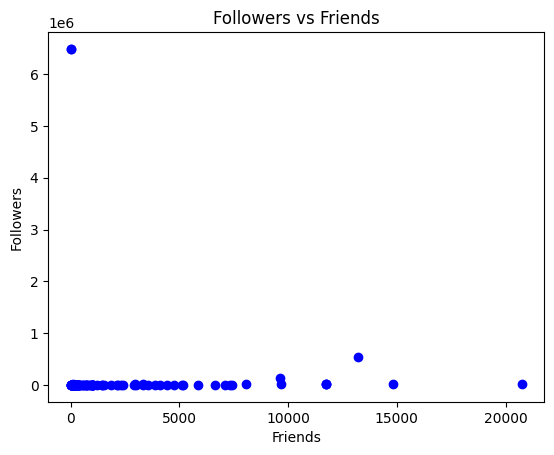

In [9]:
import matplotlib.pyplot as plt

plt.scatter(df['friends'], df['followers'], color='blue')
plt.xlabel('Friends')
plt.ylabel('Followers')
plt.title('Followers vs Friends')
plt.show()

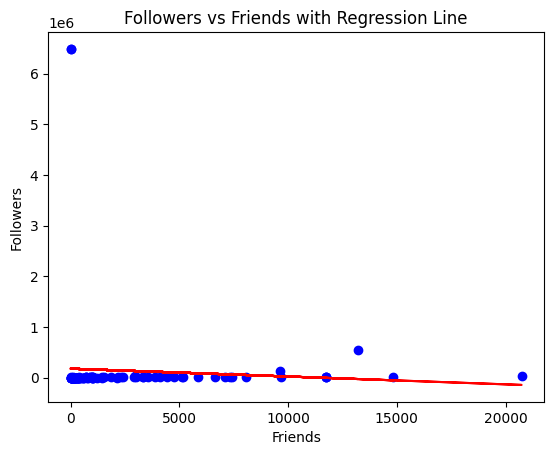

In [10]:
# Regression line
predictions = model.predict(X)

plt.scatter(df['friends'], df['followers'], color='blue')
plt.plot(df['friends'], predictions, color='red')  # regression line
plt.xlabel('Friends')
plt.ylabel('Followers')
plt.title('Followers vs Friends with Regression Line')
plt.show()

In [13]:
# Save the collected tweets to CSV
df.to_csv('result.csv', index=False)
print("CSV saved successfully!")

CSV saved successfully!


In [14]:
from google.colab import files
files.download('result.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>